# EXPRESSIVE PUNCTUATION PATTERNS

## Pre-Processsing

In [1]:
import datasets
from datasets import load_dataset

tldr = load_dataset("webis/tldr-17", split = 'train[:30%]') # only 30% of data is used to train 

C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\jslui\anaconda3\envs\docana\lib\site-packages\datasets\table.py:1421: FutureWarning: promote has been superseded by promote_options='default'.
  table = cls._concat_blocks(blocks, axis=0)


In [2]:
# 3 random examples from the Webis-TLDR-17 TIFU dataset:
import random

def show_random_elements(dataset, num_examples=3):
    picks = random.sample(range(len(dataset)), num_examples)
    for i in picks:
        print(dataset[i])
        print("---")

show_random_elements(tldr)

{'author': '_AlphaZulu_', 'body': "There was this cute receptionist at work that was new. For several weeks, every time I would walk by she'd make eye contact and smile. Even if I had walked by an hour earlier, she made it clear to make eye contact and smile. Even when I was walking by with a co-worker she would make eye contact with me. Finally after several weeks, I found the courage to just talk to her. We had a short 3-5 minute chat (a LOT of other employees would stop and chat her up and waste a lot of time because she was young and attractive). I kept the conversation light hearted and fun, she even laughed a couple of times. Anyways, walked away from the conversation with her number and e-mail address. The next day I text her to meet up for a cup of coffee or something along those lines. No answer. Texted her again a few days later (didn't want to seem stalkerish/desperate), still no answer. So I gave up. She as a part time employee, so the next time she was at work, she didn't 

## Subreddit Selection

In [3]:
subreddit_count = {}

for subreddit in tldr['subreddit']:
    subreddit_count[subreddit] = subreddit_count.get(subreddit, 0) + 1

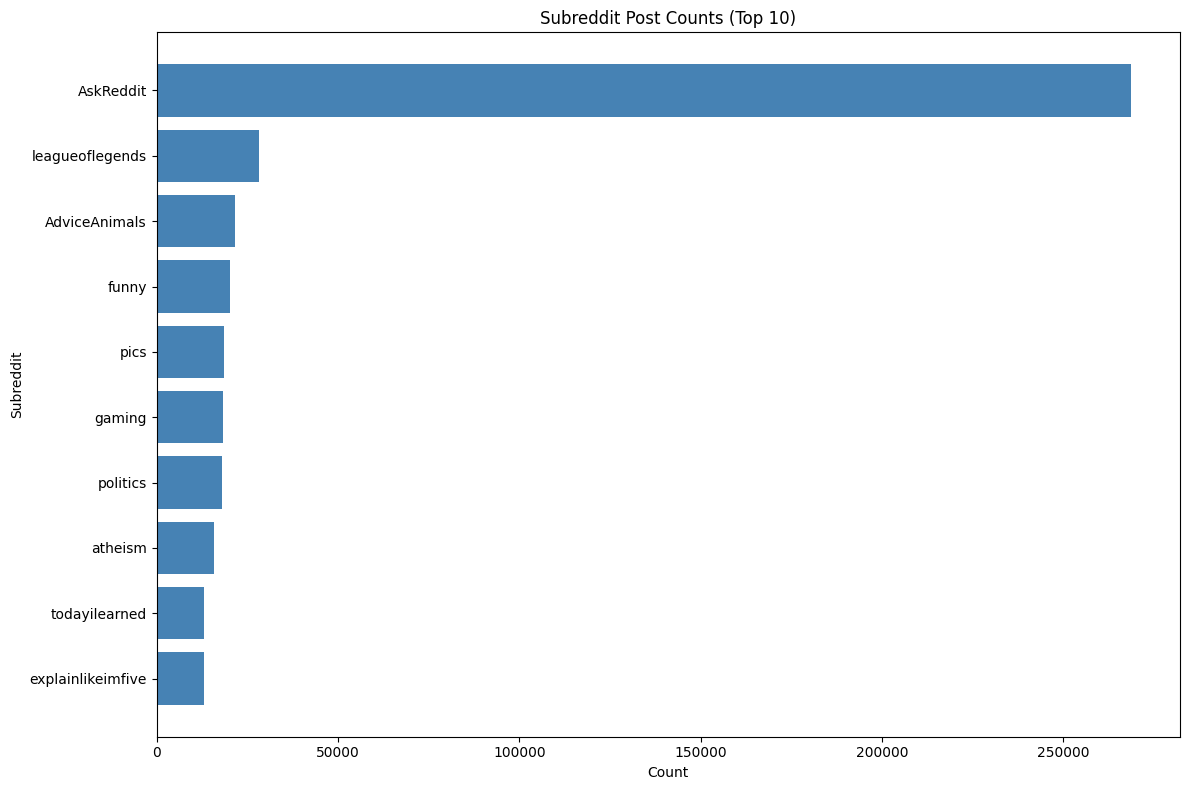

In [4]:
import matplotlib.pyplot as plt

# Sort by count descending and take top 10
subs_10 = sorted(subreddit_count.items(), key=lambda x: x[1], reverse=True)[:10]
subreddits, counts = zip(*subs_10)

plt.figure(figsize=(12, 8))
plt.barh(subreddits, counts, color='steelblue')
plt.xlabel('Count')
plt.ylabel('Subreddit')
plt.title('Subreddit Post Counts (Top 10)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [5]:
# subreddits is a tuple of names from the chart above, e.g. ('AskReddit', 'tifu', ...)
top_10_subs = list(subreddits)

# filter dataset to only posts from those top 10 subreddits
dfilt = tldr.filter(lambda x: x['subreddit'] in top_10_subs)
print(top_10_subs)

['AskReddit', 'leagueoflegends', 'AdviceAnimals', 'funny', 'pics', 'gaming', 'politics', 'atheism', 'todayilearned', 'explainlikeimfive']


## Calculation of Frequencies
### Tokenization and calculation of Punctuation frequencies
We use 1000 as max number of posts to reduce the runtime.

In [6]:
from collections import Counter
import nltk
import string

def get_punctuation_counts(subreddit, max_posts=1000):
    punctuation = []
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        tokens = nltk.word_tokenize(text)
        punctuation.extend([t for t in tokens if t in string.punctuation])
        count += 1
        if count >= max_posts:
            break
    return Counter(punctuation)

### Average words between punctuation

In [7]:
def get_avg_sentence_length(subreddit, max_posts=1000):
    total_words = 0
    total_sentences = 0
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        sentences = nltk.sent_tokenize(text)
        for sent in sentences:
            sent_tokens = nltk.word_tokenize(sent)
            words = [t for t in sent_tokens if t not in string.punctuation]
            total_words += len(words)
            total_sentences += 1
        count += 1
        if count >= max_posts:
            break
    return (total_words / total_sentences) if total_sentences > 0 else 0.0


### Average sentence length

In [8]:
def get_avg_words_between_punct(subreddit, max_posts=1000):
    total_intervals = 0
    total_words = 0
    count = 0
    for row in dfilt:
        if row['subreddit'] != subreddit:
            continue
        text = str(row['content'])
        tokens = nltk.word_tokenize(text)
        words_since_punct = 0
        for token in tokens:
            if token in string.punctuation:
                total_intervals += 1
                total_words += words_since_punct
                words_since_punct = 0
            else:
                words_since_punct += 1
        # to count trailing words after last punctuation,if need be
        # if words_since_punct > 0:
        #     total_intervals += 1
        #     total_words += words_since_punct
        count += 1
        if count >= max_posts:
            break
    return (total_words / total_intervals) if total_intervals > 0 else 0.0

### Printing & Saving Results

In [11]:
# Loop through subreddits and print results
results = []
for sub in top_10_subs:
    punct_counts = get_punctuation_counts(sub)
    avg_sent_len = get_avg_sentence_length(sub)
    avg_words_punct = get_avg_words_between_punct(sub)
    results.append({
        "subreddit": sub,
        "punctuation_counts": punct_counts,
        "avg_sentence_length": avg_sent_len,
        "avg_words_between_punct": avg_words_punct
    })
    print(f"\n{sub}")
    print("punctuation_counts:", punct_counts)
    print("avg_sentence_length:",avg_sent_len)
    print("avg_words_between_punct:", avg_words_punct)


AskReddit
punctuation_counts: Counter({'.': 11483, ',': 9673, '(': 1077, ')': 1047, '?': 494, '!': 403, ':': 390, "'": 177, '-': 175, ';': 114, '$': 107, '[': 69, ']': 68, '%': 56, '>': 41, '&': 29, '#': 18, '*': 11, '/': 10, '+': 8, '=': 6, '<': 5, '@': 1, '{': 1, '}': 1, '~': 1, '|': 1})
avg_sentence_length: 17.716472945891784
avg_words_between_punct: 8.650396607241028

leagueoflegends
punctuation_counts: Counter({'.': 7396, ',': 6779, ')': 1038, '(': 1028, '?': 460, ':': 378, '%': 220, '-': 185, '>': 170, '!': 140, '[': 133, ']': 132, ';': 111, '+': 107, "'": 60, '/': 44, '=': 44, '&': 23, '#': 20, '*': 19, '@': 14, '$': 13, '<': 12, '~': 4, '_': 3, '`': 1})
avg_sentence_length: 20.262064752596213
avg_words_between_punct: 8.87843962447394

AdviceAnimals
punctuation_counts: Counter({'.': 8469, ',': 7473, '(': 930, ')': 925, '?': 553, ':': 309, '!': 265, "'": 171, '-': 159, ';': 119, '$': 117, '%': 96, '>': 62, ']': 57, '[': 54, '#': 42, '&': 36, '*': 19, '/': 10, '@': 4, '+': 4, '~'

### Visualization

In [ ]:
#CODE FOR GRAPH

## Using a classifier to predict the subreddit based on punctuation

### Frequency per 100 words
We calculate the punctuation frequency per 100 words for 500 posts of each of the 10 subreddits we chose. Then turn that into a csv file.

In [13]:
import pandas as pd

PUNCT_LIST = list(string.punctuation)

def extract_punct_features(text):
    tokens = nltk.word_tokenize(text)
    words = [t for t in tokens if t not in string.punctuation]
    n_words = len(words)
    counts = Counter(t for t in tokens if t in string.punctuation)
    if n_words == 0:
        return {p: 0.0 for p in PUNCT_LIST}
    return {p: (counts.get(p, 0) / n_words) * 100 for p in PUNCT_LIST}

# Build one row per post: punctuation frequencies + subreddit label
MAX_POSTS_PER_SUB = 500  #for reasonable time 

post_counts = {sub: 0 for sub in top_10_subs}
rows = []

for row in dfilt:
    sub = row['subreddit']
    if post_counts[sub] >= MAX_POSTS_PER_SUB:
        continue
    feats = extract_punct_features(row['content'])
    feats['subreddit'] = sub
    rows.append(feats)
    post_counts[sub] += 1
    if all(c >= MAX_POSTS_PER_SUB for c in post_counts.values()):
        break
punct_df = pd.DataFrame(rows)
punct_df = punct_df[['subreddit'] + [c for c in punct_df.columns if c != 'subreddit']]
punct_df.to_csv('punctuation_features.csv', index=False)
punct_df.head()

,subreddit,!,"""",#,$,%,&,',(,),...,[,\,],^,_,`,{,|,},~
0,funny,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,1.948052,1.948052,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,atheism,0.787402,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AskReddit,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,leagueoflegends,0.000000,0.0,0.0,0.0,0.0,0.0,1.086957,1.086957,1.086957,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AskReddit,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Classifier and Scores
The model studies to find correlation between the punctuation and the subreddit. The guesses of the 200 trees(n_estimator) is then averaged during prediction. Random Forest Classifier learns the rules and takes a majority vote from the different trees.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X = punct_df.drop(columns=['subreddit'])
y = punct_df['subreddit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print("CLASSIFICATION REPORT")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT
Accuracy: 0.136
                   precision    recall  f1-score   support

    AdviceAnimals       0.12      0.11      0.12       100
        AskReddit       0.11      0.15      0.13       100
          atheism       0.14      0.15      0.15       100
explainlikeimfive       0.15      0.19      0.17       100
            funny       0.11      0.08      0.09       100
           gaming       0.14      0.13      0.14       100
  leagueoflegends       0.10      0.11      0.11       100
             pics       0.14      0.13      0.14       100
         politics       0.20      0.19      0.20       100
    todayilearned       0.14      0.12      0.13       100

         accuracy                           0.14      1000
        macro avg       0.14      0.14      0.14      1000
     weighted avg       0.14      0.14      0.14      1000



### Visualization

In [ ]:
#CODE FOR GRAPH